# Tarea 1 — Análisis exploratorio de datos

**Jaime Bidart**

**Vanessa Salgado**

## ¿Está temblando más?

**Pregunta de investigación**

> **¿El aumento en el número de terremotos registrados se sostiene al separar los eventos por magnitud?**

La pregunta inicial es bastante simple ¿realmente está temblando más que antes? Si miramos solo el número de registros por año, pareciera que sí, porque hoy aparecen muchos más terremotos que hace unas décadas. Pero eso no significa necesariamente que estén ocurriendo más terremotos. El catálogo también depende de cuántos instrumentos existen, dónde están ubicados y qué tan bien pueden detectar los eventos.

Para separar un poco ambas cosas, vamos a comparar los terremotos según su magnitud. La idea es que los eventos pequeños son mucho más sensibles a cambios en la capacidad de detección, mientras que los terremotos grandes son más fáciles de registrar incluso con redes menos completas.


Si realmente hubiera aumentado la sismicidad global de forma más o menos uniforme, esperaríamos ver ese aumento en terremotos de distintas magnitudes, no solo en los más pequeños. En cambio, si la diferencia se debe principalmente a cambios en la capacidad de detección del catálogo, tendría sentido que el aumento apareciera sobre todo cerca de su límite inferior de magnitud. Esa comparación es la que guía el resto del análisis.

## 1. Carga de datos y preparación

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
PALETA = plt.cm.viridis(np.linspace(0.08, 0.85, 5))

candidatos = [Path(c) / 'earthquakes_usgs.csv'
              for c in ['.', '/content', '/mnt/user-data/uploads', '..']]
candidatos += [Path(c) / 'earthquakes.csv'
               for c in ['.', '/content', '/mnt/user-data/uploads', '..']]
ruta = next(p for p in candidatos if p.exists())
crudo = pd.read_csv(ruta)
print(f'Archivo: {ruta}   filas: {len(crudo):,}   columnas: {crudo.shape[1]}')
crudo.head(3)

Archivo: earthquakes_usgs.csv   filas: 310,535   columnas: 13


,Unnamed: 0,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms
0,0,1900-01-05T19:00:00.000Z,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN
1,1,1900-01-11T09:07:00.000Z,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN
2,2,1900-01-20T06:33:00.000Z,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN


## 2. ¿Qué estamos contando?

Cada fila corresponde a un evento registrado por el USGS. La mayoría son terremotos, pero el catálogo también incluye algunos otros eventos, como explosiones nucleares o erupciones. Por eso, antes de analizar los datos conviene tener claro qué representa cada registro y qué variables tenemos disponibles.

La muestra que usamos corresponde a los eventos incluidos en este archivo, así que no necesariamente representa todos los sismos que ocurrieron en el planeta.

| Variable | Qué información entrega |
|---|---|
| `time` | Fecha y hora del evento; la usamos para construir las series por año |
| `latitude`, `longitude` | Ubicación del epicentro |
| `depth` | Profundidad del hipocentro en km |
| `mag`, `magType` | Magnitud del evento y método con que fue estimada |
| `type` | Tipo de evento; nos permite quedarnos solo con terremotos |
| `nst`, `rms` | Información asociada a cómo fue determinado el evento |

In [3]:
calidad = pd.DataFrame({'tipo': crudo.dtypes.astype(str),
                        'faltantes': crudo.isna().sum(),
                        '% faltante': crudo.isna().mean().mul(100).round(1)})
display(calidad)
display(crudo['type'].value_counts().head(5).rename('eventos').to_frame())

,tipo,faltantes,% faltante
Unnamed: 0,int64,0,0.0
time,object,0,0.0
latitude,float64,0,0.0
longitude,float64,0,0.0
depth,float64,727,0.2
mag,float64,0,0.0
magType,object,1,0.0
place,object,0,0.0
type,object,0,0.0
status,object,0,0.0


,eventos
type,
earthquake,309821
nuclear explosion,614
volcanic eruption,71
explosion,16
mine collapse,6


**Tres cosas a tener en cuenta sobre la muestra:**

1. `nst` y `rms` tienen bastantes valores faltantes (61 % y 16 %). En cambio, `depth` falta en apenas un 0.23 % de los casos, y la mayoría de esos registros están en las primeras décadas del catálogo.

2. El archivo no contiene solamente terremotos, así que para el análisis nos quedamos con los eventos donde `type == 'earthquake'`.

3. El catálogo prácticamente no contiene eventos bajo M 4.5. Eso no significa que no existan terremotos más pequeños, sino que este archivo fue construido con un límite de magnitud. Por eso, todo el análisis se hace para **M ≥ 4.5** y nuestras conclusiones no se pueden extender a sismos menores.

In [4]:
df = crudo.drop(columns=['Unnamed: 0'], errors='ignore').drop_duplicates().copy()
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True, errors='coerce')
for c in ['latitude', 'longitude', 'depth', 'mag']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df[(df['type'] == 'earthquake') & df['mag'].notna() & df['time'].notna()].copy()
df['anio'] = df['time'].dt.year
df['mes'] = df['time'].dt.month

print(f'Eventos tras limpiar: {len(df):,}')
print(f'Eventos con M < 4.5: {(df.mag < 4.5).sum()}  '
      f'({(df.mag < 4.5).mean()*100:.4f} % de la muestra)')
print(f'Rango temporal: {df.anio.min()} – {df.anio.max()}')

df = df[df['mag'] >= 4.5].copy()
reciente = df[df.anio.between(1980, 2025)].copy()

Eventos tras limpiar: 309,820
Eventos con M < 4.5: 1  (0.0003 % de la muestra)
Rango temporal: 1900 – 2026


## 3. Primera mirada: sí, hay muchos más registros

Antes de comenzar a interpretar, veamos la serie completa.

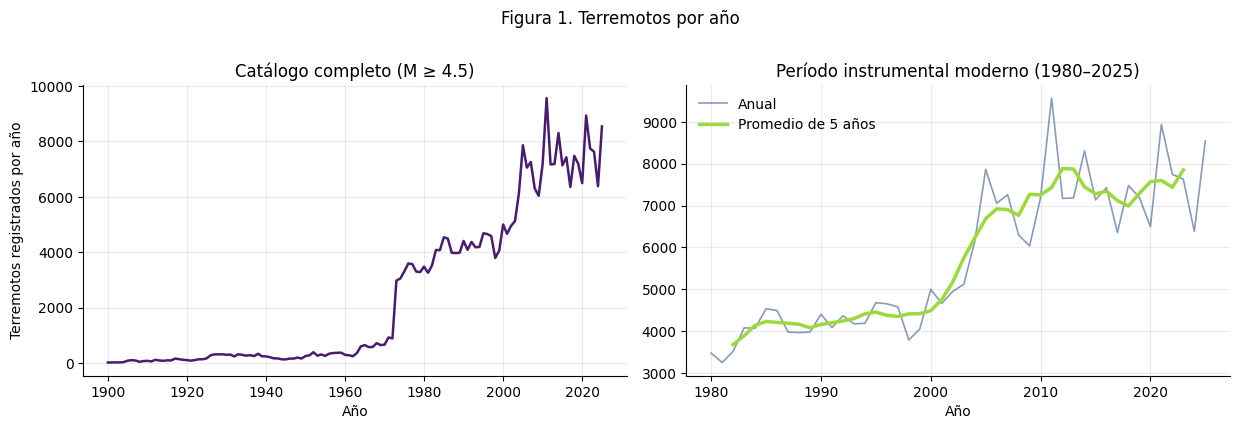

Promedio 1980–1989: 3,936 eventos/año
Promedio 2020–2025: 7,623 eventos/año


In [5]:
conteo_total = df.groupby('anio').size().reindex(range(1900, 2026), fill_value=0)

fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.2))
axs[0].plot(conteo_total.index, conteo_total.values, color=PALETA[0], lw=1.8)
axs[0].set(title='Catálogo completo (M ≥ 4.5)', xlabel='Año',
           ylabel='Terremotos registrados por año')

s = conteo_total.loc[1980:2025]
axs[1].plot(s.index, s.values, color=PALETA[1], lw=1.2, alpha=0.6, label='Anual')
axs[1].plot(s.index, s.rolling(5, center=True).mean(), color=PALETA[4], lw=2.5,
            label='Promedio de 5 años')
axs[1].set(title='Período instrumental moderno (1980–2025)', xlabel='Año')
axs[1].legend(frameon=False)
fig.suptitle('Figura 1. Terremotos por año', y=1.01)
fig.tight_layout()
plt.show()

print(f"Promedio 1980–1989: {conteo_total.loc[1980:1989].mean():,.0f} eventos/año")
print(f"Promedio 2020–2025: {conteo_total.loc[2020:2025].mean():,.0f} eventos/año")

**Interpretación.** El promedio anual pasa de unos 3.900 terremotos en 1980–1989 a unos 7.600 en 2020–2025, prácticamente el doble. Si miráramos solamente estos conteos, podríamos pensar que efectivamente está temblando más.

En el panel derecho también mostramos un **promedio de 5 años**, que suaviza las variaciones más bruscas entre un año y otro y permite ver mejor la tendencia general. Estas variaciones pueden aparecer, por ejemplo, cuando un terremoto grande genera muchas réplicas durante los meses siguientes, haciendo que un año acumule bastantes más registros de lo habitual. Más adelante analizamos un caso claro de esto en 2011.

Al promediar varios años seguidos, el efecto de estos años excepcionales pesa menos. Aun así, la tendencia sigue mostrando que durante las últimas décadas el catálogo se mantiene en niveles de registro bastante más altos que en los años ochenta. Por lo tanto, el aumento no se explica solamente por uno o dos años particularmente activos.

Sin embargo, la serie completa también muestra que el catálogo ha cambiado mucho con el tiempo. Antes de 1960 aparecen muy pocos eventos y después se observan aumentos bastante abruptos en ciertos períodos. Esto hace poco razonable interpretar toda la diferencia como un cambio real de la actividad sísmica, ya que parte de ella podría estar relacionada con cambios en la capacidad de registrar terremotos.

Por eso, el número total de eventos no es suficiente para responder nuestra pregunta. El siguiente paso será separar los registros por magnitud y ver en qué tipo de terremotos se concentra realmente este aumento.

## 4. ¿Qué pasa cuando separamos por magnitud?

En esta parte comparamos cómo cambia el número de terremotos registrados al considerar distintas magnitudes. Esto nos permite ver si el aumento que encontramos antes aparece en todo el catálogo o si se concentra solamente en los eventos más pequeños.

El **panel A** muestra, para distintos períodos, cuántos terremotos por año superan cada valor de magnitud. Como los terremotos grandes son mucho menos frecuentes que los pequeños, usamos una escala logarítmica para poder comparar todo el rango en una misma figura.

Lo interesante es comparar la separación entre las curvas. Si el aumento de registros representara un aumento más o menos uniforme de la actividad sísmica, esperaríamos encontrar diferencias entre décadas en un rango amplio de magnitudes. En cambio, si parte importante del cambio está relacionada con la capacidad de detectar eventos más pequeños, esperaríamos que las diferencias fueran mayores cerca del límite inferior del catálogo y que las curvas se acercaran al considerar magnitudes más altas.

El **panel B** muestra esta misma comparación de una forma más directa. Para cada magnitud calculamos cuántas veces mayor es la tasa de 2020–2025 respecto de la de 1980–1989. Una razón igual a 1 significa que ambos períodos tienen aproximadamente la misma cantidad de eventos por año, mientras que una razón igual a 2 significa que en el período reciente se registran aproximadamente el doble.

La zona verde muestra la incertidumbre de esta comparación. Para estimarla usamos **bootstrap por años**, es decir, repetimos el cálculo muchas veces volviendo a seleccionar años completos dentro de cada período. De esta forma incorporamos la variación que existe entre años, algo importante porque los terremotos suelen aparecer en secuencias y un evento grande puede venir acompañado de muchas réplicas.

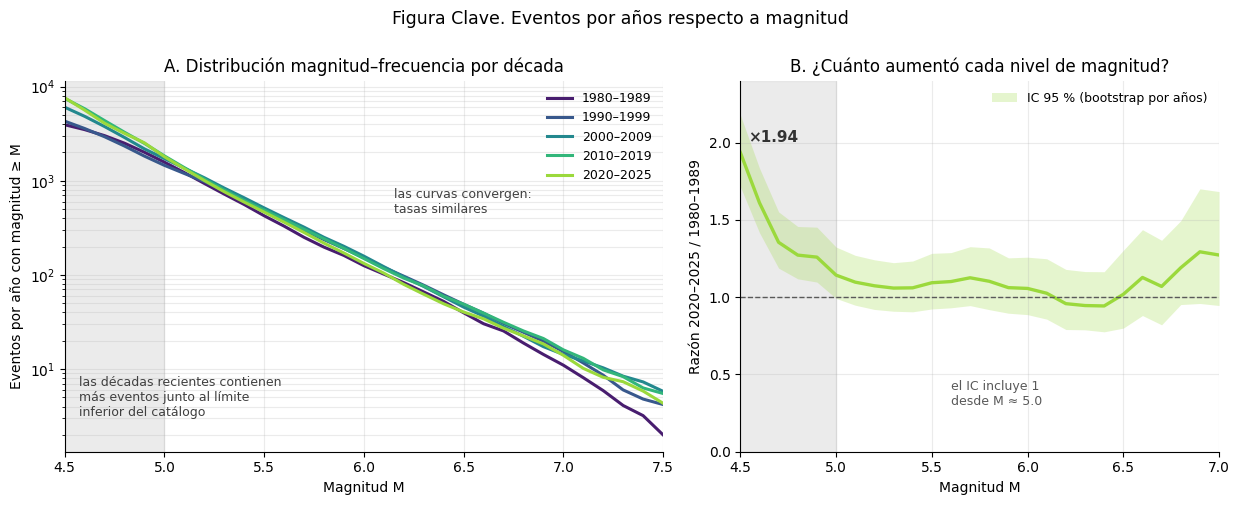

M ≥ 4.5:  razón = 1.94   IC 95 % = [1.72, 2.18]
M ≥ 5.0:  razón = 1.14   IC 95 % = [0.99, 1.32]
M ≥ 5.5:  razón = 1.09   IC 95 % = [0.92, 1.28]
M ≥ 6.0:  razón = 1.06   IC 95 % = [0.89, 1.26]
M ≥ 7.0:  razón = 1.27   IC 95 % = [0.95, 1.68]


In [12]:
periodos = {'1980–1989': (1980, 1989), '1990–1999': (1990, 1999),
            '2000–2009': (2000, 2009), '2010–2019': (2010, 2019),
            '2020–2025': (2020, 2025)}
magnitudes = np.arange(4.5, 7.51, 0.1)

# Matriz (años x magnitudes): número de eventos con magnitud >= M en cada año
def conteos_por_anio(sub, rango_anios, grilla):
    return np.array([[(sub.loc[sub.anio == a, 'mag'] >= m).sum() for m in grilla]
                     for a in rango_anios], dtype=float)

tasa = {}
for etiqueta, (a, b) in periodos.items():
    sub = df[df.anio.between(a, b)]
    tasa[etiqueta] = np.array([(sub.mag >= m).sum() for m in magnitudes]) / (b - a + 1)

# Razón de tasas anuales y su IC 95 %, remuestreando años completos con reemplazo
def razon_bootstrap(sub, anios_viejos, anios_nuevos, grilla, n_rep=2000, semilla=0):
    rng = np.random.default_rng(semilla)
    v = conteos_por_anio(sub, anios_viejos, grilla)
    n = conteos_por_anio(sub, anios_nuevos, grilla)
    razon = n.mean(axis=0) / v.mean(axis=0)
    iv = rng.integers(0, len(v), (n_rep, len(v)))
    inu = rng.integers(0, len(n), (n_rep, len(n)))
    muestras = n[inu].mean(axis=1) / v[iv].mean(axis=1)
    return razon, np.percentile(muestras, [2.5, 97.5], axis=0)

mags_b = np.arange(4.5, 7.01, 0.1)
razon, ic = razon_bootstrap(df, range(1980, 1990), range(2020, 2026), mags_b)

fig, axs = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw={'width_ratios': [1.25, 1]})

ax = axs[0]
for (etiqueta, valores), color in zip(tasa.items(), PALETA):
    ax.semilogy(magnitudes, valores, color=color, lw=2.2, label=etiqueta)
ax.axvspan(4.5, 5.0, color='0.85', alpha=0.5, zorder=0)
ax.text(4.57, 3.2, 'las décadas recientes contienen\nmás eventos junto al límite\ninferior del catálogo',
        fontsize=9, color='0.25')
ax.text(6.15, 450, 'las curvas convergen:\ntasas similares', fontsize=9, color='0.25')
ax.set(xlabel='Magnitud M', ylabel='Eventos por año con magnitud ≥ M', xlim=(4.5, 7.5),
       title='A. Distribución magnitud–frecuencia por década')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25, which='both')

ax = axs[1]
ax.fill_between(mags_b, ic[0], ic[1], color=PALETA[4], alpha=0.25, lw=0,
                label='IC 95 % (bootstrap por años)')
ax.plot(mags_b, razon, color=PALETA[4], lw=2.4)
ax.axhline(1, color='0.35', ls='--', lw=1)
ax.axvspan(4.5, 5.0, color='0.85', alpha=0.5, zorder=0)
ax.annotate(f'×{razon[0]:.2f}', (4.54, razon[0] + 0.07), fontsize=11, color='0.2', weight='bold')
ax.annotate('el IC incluye 1\ndesde M ≈ 5.0', (5.6, 0.3), fontsize=9, color='0.35')
ax.set(xlabel='Magnitud M', ylabel='Razón 2020–2025 / 1980–1989', xlim=(4.5, 7.0),
       ylim=(0, 2.4), title='B. ¿Cuánto aumentó cada nivel de magnitud?')
ax.legend(frameon=False, fontsize=9, loc='upper right')

fig.suptitle('Figura Clave. Eventos por años respecto a magnitud',
             fontsize=12.5, y=1.0)
fig.tight_layout()
plt.show()

for m in [4.5, 5.0, 5.5, 6.0, 7.0]:
    i = int(np.argmin(abs(mags_b - m)))
    print(f'M ≥ {m}:  razón = {razon[i]:.2f}   IC 95 % = [{ic[0][i]:.2f}, {ic[1][i]:.2f}]')

In [7]:
# Tasas anuales y pendiente de la distribución magnitud-frecuencia por década.
# El valor b se estima con el método de máxima verosimilitud de Aki-Utsu sobre los eventos
# individuales con M >= 5.5, que no depende de un ajuste sobre conteos acumulados correlacionados.
filas = {}
for etiqueta, (a, b) in periodos.items():
    sub = df[df.anio.between(a, b)]
    n = b - a + 1
    fila = {f'M ≥ {m}': (sub.mag >= m).sum() / n for m in [4.5, 5.0, 5.5, 6.0, 7.0]}
    m_alta = sub.loc[sub.mag >= 5.5, 'mag']
    fila['b (Aki, M≥5.5)'] = np.log10(np.e) / (m_alta.mean() - (5.5 - 0.05))
    fila['error de b'] = fila['b (Aki, M≥5.5)'] / np.sqrt(len(m_alta))
    filas[etiqueta] = fila

tabla = pd.DataFrame(filas).T
display(tabla.round({c: 0 for c in tabla.columns[:-2]} |
                    {'b (Aki, M≥5.5)': 2, 'error de b': 2}))

,M ≥ 4.5,M ≥ 5.0,M ≥ 5.5,M ≥ 6.0,M ≥ 7.0,"b (Aki, M≥5.5)",error de b
1980–1989,3936.0,1575.0,425.0,125.0,11.0,1.06,0.02
1990–1999,4299.0,1458.0,484.0,153.0,15.0,1.01,0.01
2000–2009,6038.0,1719.0,515.0,158.0,14.0,1.03,0.01
2010–2019,7502.0,1837.0,489.0,149.0,16.0,1.01,0.01
2020–2025,7623.0,1800.0,465.0,132.0,14.0,1.06,0.02


### ¿Qué nos muestra esta figura?

Primero separemos lo que muestran los datos de la interpretación que hacemos a partir de esto.

**Observación.** El aumento de registros no aparece de la misma forma en todas las magnitudes.

- Para **M ≥ 4.5**, la tasa anual casi se duplica. La razón entre 2020–2025 y 1980–1989 es **1.94**, con un intervalo de confianza del 95 % de **[1.72, 2.17]**.

- Desde aproximadamente **M = 5.0**, la diferencia entre los dos períodos se hace mucho menor. Para M ≥ 5.0 la razón es **1.14 [0.99, 1.31]**, para M ≥ 5.5 es **1.09 [0.92, 1.28]** y para M ≥ 6.0 es **1.06 [0.88, 1.26]**. En todos estos casos el intervalo incluye 1, por lo que los datos son compatibles con tasas parecidas entre los períodos.

- Para **M ≥ 7.0** la razón vuelve a subir a **1.27**, pero el intervalo es bastante más amplio, **[0.94, 1.68]**. En este rango hay solamente unos 11–14 eventos por año, así que la variación entre años es demasiado grande como para sacar una conclusión clara.

También podemos comparar la forma de las curvas usando el parámetro **b** de la relación magnitud-frecuencia. Para los eventos con M ≥ 5.5 obtenemos valores de **1.06, 1.01, 1.03, 1.01 y 1.06** para los distintos períodos, con errores de alrededor de 0.01–0.02. En otras palabras, la forma de la distribución entre terremotos grandes y pequeños se mantiene bastante parecida entre las décadas. Esto no significa que ocurra exactamente la misma cantidad de terremotos, sino que la proporción entre las distintas magnitudes es similar.

**Interpretación.** Si realmente hubiera aumentado la sismicidad global de forma más o menos uniforme, manteniendo una distribución de magnitudes parecida, esperaríamos ver diferencias entre décadas en un rango más amplio de magnitudes. Sin embargo, las curvas se separan principalmente cerca del límite inferior del catálogo y se acercan bastante a medida que consideramos terremotos más grandes.

Este comportamiento es compatible con que una gran parte de este aumento se deba a una mejor capacidad para registrar eventos de magnitud moderada. De todas formas, esta figura por sí sola no permite decir que esa sea la única causa. Más adelante veremos que `magType` también cambia entre décadas, por lo que los distintos métodos utilizados para estimar la magnitud y los cambios en las redes que aportan datos al catálogo también pueden influir.

Lo que sí se puede concluir de esta figura es que este aumento de registros se concentra más cerca de las magnitudes menores del catálogo. Por eso, el aumento que vimos inicialmente no se puede interpretar simplemente como que hoy ocurren el doble de terremotos.

El panel B llega solamente hasta **M = 7.0**, porque por encima de ese valor quedan muy pocos eventos por año y la razón empieza a variar demasiado. El panel A llega hasta M = 7.5 para mostrar que las curvas de los distintos períodos siguen siendo bastante parecidas también en las magnitudes más altas.

## 5. Contexto: ¿el patrón se repite en distintas regiones?

Un resultado global podría estar dominado por una sola región con una red sísmica muy densa. Para
comprobarlo, dividimos la muestra en tres ventanas geográficas definidas **antes** de comparar, y
repetimos la prueba en cada una: evolución de M ≥ 4.5 frente a M ≥ 5.5, cada serie normalizada por
su propio promedio de los años ochenta.

Son recortes rectangulares, no países ni placas tectónicas, y no tienen la misma área. Por eso
comparamos evolución relativa y no cuál región tiembla más.

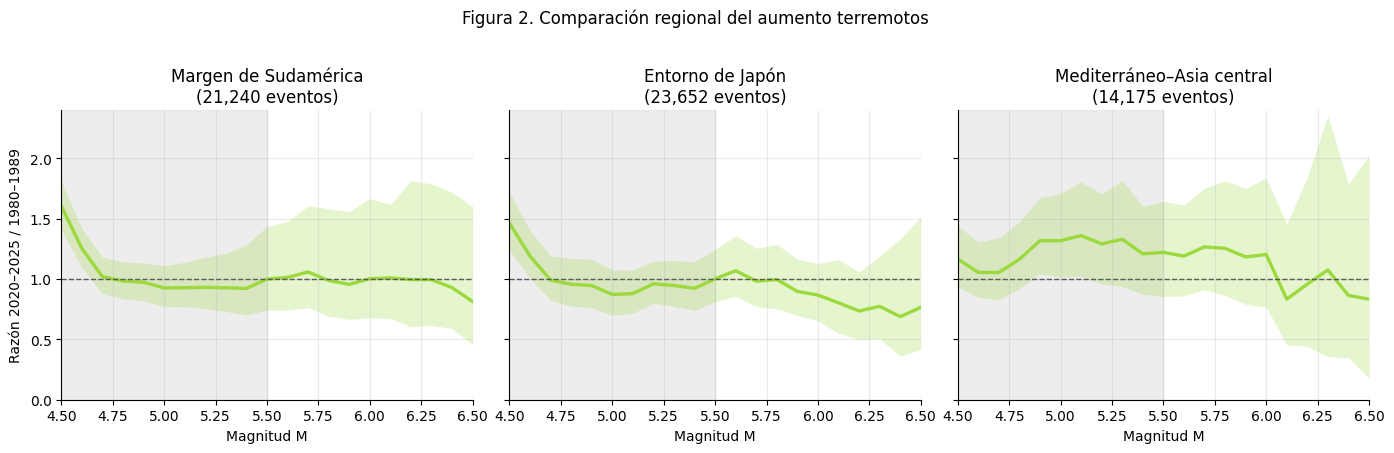

,M ≥ 4.5,M ≥ 5.5
Margen de Sudamérica,"1.61 [1.41, 1.81]","1.00 [0.74, 1.43]"
Entorno de Japón,"1.46 [1.24, 1.72]","1.00 [0.81, 1.24]"
Mediterráneo–Asia central,"1.17 [0.94, 1.44]","1.22 [0.86, 1.64]"


In [8]:
regiones = {
    'Margen de Sudamérica': lambda d: d.latitude.between(-60, 15) & d.longitude.between(-85, -60),
    'Entorno de Japón':     lambda d: d.latitude.between(25, 50) & d.longitude.between(125, 150),
    'Mediterráneo–Asia central': lambda d: d.latitude.between(25, 50) & d.longitude.between(10, 80),
}
anios = np.arange(1980, 2026)
mags_reg = np.arange(4.5, 6.51, 0.1)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
resumen = {}
for ax, (nombre, mascara) in zip(axs, regiones.items()):
    sub = reciente[mascara(reciente)]
    viejo = sub[sub.anio <= 1989]
    nuevo = sub[sub.anio >= 2020]
    r, ic_r = razon_bootstrap(sub, range(1980, 1990), range(2020, 2026), mags_reg)
    ax.fill_between(mags_reg, ic_r[0], ic_r[1], color=PALETA[4], alpha=0.25, lw=0)
    ax.plot(mags_reg, r, color=PALETA[4], lw=2.4)
    ax.axhline(1, color='0.35', ls='--', lw=1)
    ax.axvspan(4.5, 5.5, color='0.85', alpha=0.45, zorder=0)
    ax.set(title=f'{nombre}\n({len(sub):,} eventos)', xlabel='Magnitud M',
           xlim=(4.5, 6.5), ylim=(0, 2.4))
    i45, i55 = 0, int(np.argmin(abs(mags_reg - 5.5)))
    resumen[nombre] = {
        'M ≥ 4.5': f'{r[i45]:.2f}  [{ic_r[0][i45]:.2f}, {ic_r[1][i45]:.2f}]',
        'M ≥ 5.5': f'{r[i55]:.2f}  [{ic_r[0][i55]:.2f}, {ic_r[1][i55]:.2f}]'}
axs[0].set_ylabel('Razón 2020–2025 / 1980–1989')
fig.suptitle('Figura 2. Comparación regional del aumento terremotos', y=1.02)
fig.tight_layout()
plt.show()

display(pd.DataFrame(resumen).T)

### ¿Qué vemos al separar por regiones?

En **Sudamérica y Japón** aparece un comportamiento bastante parecido al que vimos con el catálogo completo. La razón parte en **1.61** y **1.46** para M ≥ 4.5, pero baja rápidamente hasta valores cercanos a 1 antes de M ≈ 4.8 y se mantiene alrededor de ese valor para magnitudes mayores.

Esto muestra que, nuevamente, la diferencia entre los años ochenta y el período reciente se concentra principalmente en los terremotos de menor magnitud del catálogo. Al considerar terremotos más grandes, las tasas entre ambos períodos pasan a ser bastante parecidas.

En **Mediterráneo–Asia central** vemos algo distinto. La razón se mantiene cerca de 1.2 en buena parte del rango, pero los intervalos de confianza son bastante amplios: para M ≥ 4.5 obtenemos **1.17 [0.94, 1.44]** y para M ≥ 5.5 **1.22 [0.86, 1.64]**. Como ambos intervalos incluyen 1, con estos datos no podemos decir que exista un cambio claro entre los dos períodos en esta región.

Por lo tanto, el resultado que encontramos antes no parece depender solamente de una región en particular. En Sudamérica y Japón el aumento vuelve a concentrarse cerca del límite inferior de magnitud, mientras que en Mediterráneo–Asia central no encontramos una diferencia clara. Esto refuerza la idea de que el aumento general de registros no se distribuye de la misma forma entre todas las magnitudes.

## 6. Analisis del año con más eventos

Si buscamos el año con más registros, se esperaria obtener unos de los últimos años, y que dentro de este la cantidad de sismos se distribuya de igual forma.

Pero esto no ocurre así, el año con más sismos detectados corresponde al 2011, para ver como se distribuye en todo el año, generamos un gráfico por meses.

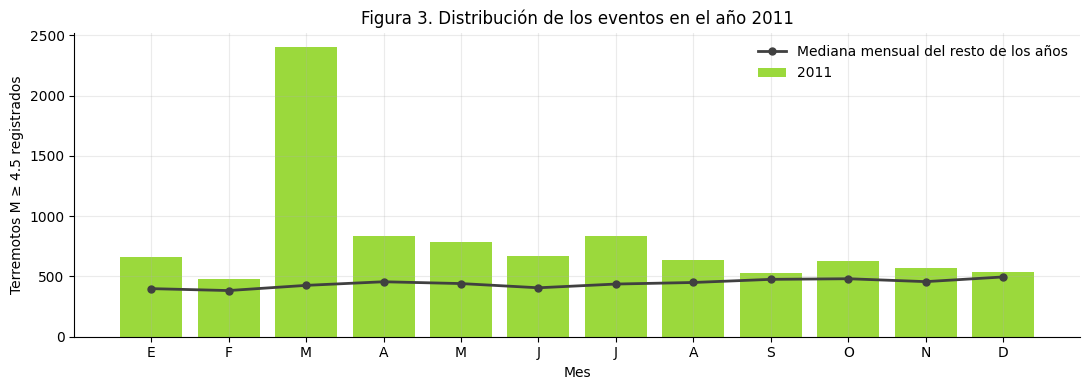

Año con más registros: 2011 (9,568 eventos)
Marzo de 2011: 2,401 eventos (mediana del resto: 426)
Exceso total del año: 4,260; exceso solo de marzo: 1,975 (46 % del exceso anual)

De los 2,401 eventos de marzo 2011, 1,956 (81 %) caen frente a Japón (30–45 N, 135–150 E)
Mediana de eventos en esa misma ventana en marzo de los demás años: 20


In [9]:
conteo_45 = reciente.groupby('anio').size().reindex(anios, fill_value=0)
anio_pico = int(conteo_45.idxmax())

mensual = (pd.crosstab(reciente.anio, reciente.mes)
           .reindex(index=anios, columns=range(1, 13), fill_value=0))
referencia = mensual.drop(index=anio_pico).median()

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(1, 13)
ax.bar(x, mensual.loc[anio_pico], color=PALETA[4], label=f'{anio_pico}')
ax.plot(x, referencia, color='0.25', lw=2, marker='o', ms=5,
        label='Mediana mensual del resto de los años')
ax.set(xticks=x, xticklabels=['E','F','M','A','M','J','J','A','S','O','N','D'],
       xlabel='Mes', ylabel='Terremotos M ≥ 4.5 registrados',
       title=f'Figura 3. Distribución de los eventos en el año 2011')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f'Año con más registros: {anio_pico} ({conteo_45.max():,} eventos)')
print(f'Marzo de {anio_pico}: {mensual.loc[anio_pico, 3]:,} eventos '
      f'(mediana del resto: {referencia[3]:.0f})')
exceso = mensual.loc[anio_pico].sum() - referencia.sum()
exceso_marzo = mensual.loc[anio_pico, 3] - referencia[3]
print(f'Exceso total del año: {exceso:,.0f}; exceso solo de marzo: {exceso_marzo:,.0f} '
      f'({exceso_marzo/exceso*100:.0f} % del exceso anual)')

# Comprobación espacial: ¿dónde ocurrieron los eventos de ese mes?
ventana = lambda d: d.latitude.between(30, 45) & d.longitude.between(135, 150)
marzo = reciente[(reciente.anio == anio_pico) & (reciente.mes == 3)]
otros = reciente[(reciente.anio != anio_pico) & (reciente.mes == 3)]
print(f'\nDe los {len(marzo):,} eventos de marzo {anio_pico}, '
      f'{ventana(marzo).sum():,} ({ventana(marzo).mean()*100:.0f} %) caen frente a Japón '
      f'(30–45 N, 135–150 E)')
print(f'Mediana de eventos en esa misma ventana en marzo de los demás años: '
      f'{otros[ventana(otros)].groupby("anio").size().median():.0f}')

El año con más registros del período es el año 2011, y su exceso no
está repartido a lo largo del año, marzo por sí solo corresponde cerca del 46 % del exceso de todo el año.

Luego de una investigación, se encontró que el año ocurrió el terremoto de Tohoku (M 9.1). Por lo que consideramos que el aumento de temblores es debido a las posibles replicas generadas a partir de este terremoto de gran magnitud, probablemente este aumento excesivo de datos está concentrado en el periodo de tiempo cercano a este evento.

Luego de buscar información, efectivamente se trata de réplicas de Tohoku, el exceso debería estar concentrado frente a la costa de Japón (donde ocurrio el terremoto). Efectivamente el
81 % de los eventos de marzo de 2011 caen en una ventana de 15° × 15° alrededor del epicentro. En conclusión la comprobación es consistente con la
hipótesis.

Este analisis es importante para nuestro analisis ya que las filas del catálogo no son observaciones independientes.
Un solo terremoto grande puede aumentar la cantidad anual de eventos de forma excesiva, de modo que cualquier afirmación sobre
tendencias basada en conteos no son del todo confiables. Esto no cambia nuestra conclusión, porque las réplicas
son mayoritariamente de magnitud baja y nuestra prueba se apoya en las magnitudes altas, pero sí
refuerza el por qué no debemos leer la Figura 1 literalmente.

## 7. Limitaciones del catálogo

Dentro del dataset detectamos 3 limitaciones. La escala de magnitud no es la misma a lo largo del tiempo. `magType` cambia
sistemáticamente, y además cambia de forma según el rango de magnitud.

In [10]:
reciente = reciente.assign(decada=(reciente.anio // 10 * 10),
                           escala=reciente.magType.str.lower())
bajo = reciente[reciente.mag.between(4.5, 5.49)]
alto = reciente[reciente.mag >= 5.5]

for nombre, sub in [('M 4.5–5.4', bajo), ('M ≥ 5.5', alto)]:
    t = pd.crosstab(sub.decada, sub.escala, normalize='index').mul(100)
    t = t.loc[:, t.max() > 5].round(1)
    print(f'\nComposición de magType en {nombre} (% por década):')
    display(t)

faltantes = (reciente.groupby('decada')[['depth', 'nst', 'rms']]
             .apply(lambda g: g.isna().mean().mul(100)).round(1))
print('\n% de valores faltantes por década:')
display(faltantes)


Composición de magType en M 4.5–5.4 (% por década):


escala,mb,mw,mwc,mww
decada,,,,
1980,90.4,5.6,0.0,0.0
1990,85.9,5.7,4.5,0.0
2000,77.6,0.4,18.3,0.0
2010,88.1,0.6,4.1,3.4
2020,85.0,0.2,0.0,11.7



Composición de magType en M ≥ 5.5 (% por década):


escala,mb,ms,mw,mwb,mwc,mww
decada,,,,,,
1980,22.1,13.3,63.8,0.0,0.0,0.0
1990,6.0,2.7,49.8,11.0,30.1,0.0
2000,5.1,0.3,0.7,26.9,66.6,0.1
2010,7.8,0.2,1.0,10.7,14.3,65.5
2020,7.0,0.0,0.4,0.9,0.0,90.9



% de valores faltantes por década:


,depth,nst,rms
decada,,,
1980,0.0,99.1,9.8
1990,0.0,99.4,0.5
2000,0.0,3.5,4.4
2010,0.0,62.6,2.9
2020,0.0,39.6,0.1


1. En el rango bajo predomina `mb` en todas las décadas (78–90 %), mientras que sobre M 5.5 se pasó de `mw/ms` a `mwc` y finalmente a `mww`, que hoy corresponde a un 91 %. Esto tiene dos consecuencias. La primera es que la recta de la figura 4 mezcla dos escalas de magnitud distintas a ambos lados de M ≈ 5, así que su pendiente no puede leerse como un único valor b físico. La segunda es la limitación de la medición, ya que un sismo de misma magnitud pero en distintos años no fueron medidos con el mismo metodo, de modo que eventos situados cerca de un umbral podrían quedar a distinto lado de él según cómo se estimó su magnitud. Comparar cada decada consigo misma no resuelve el problema, si `mww` asigna valores algo distintos que `mw`, la comparación se ve afectada de igual forma aunque umbral/intervalo sea el mismo. Una comparación correcta necesitaria una escala común, cosa que no aparece en este dataset.

2. El catálogo no es una muestra aleatoria, está limitado en 4.5 debido a que la capacidad instrumental es muy desigual en general, lo que genera que sectores que no tienen capacidad o instrumentación de medición no son bien representados.

3. Los datos faltantes están en función del tiempo, `depth` está completa desde
1970 pero falta hasta un 21 % de los eventos de las primeras décadas del siglo XX. `nst` es más irregular, falta en más del 99 % de los eventos de los ochenta y noventa, esto baja al 3 % en los 2000 y vuelve a subir al 63 % en los 2010. Es decir, la cantidad o capacidad de los datos está directamente relacionado con la epoca que se está estudiando, que es justamente la variable que estamos comparando, y por eso no usamos `nst` ni `rms` en ningún análisis temporal.

## 8. Estructura espacial de la profundidad
Podemos también analizar la distribución de los sismos y categorizar por profundidad. Para esto generamos un mapa.

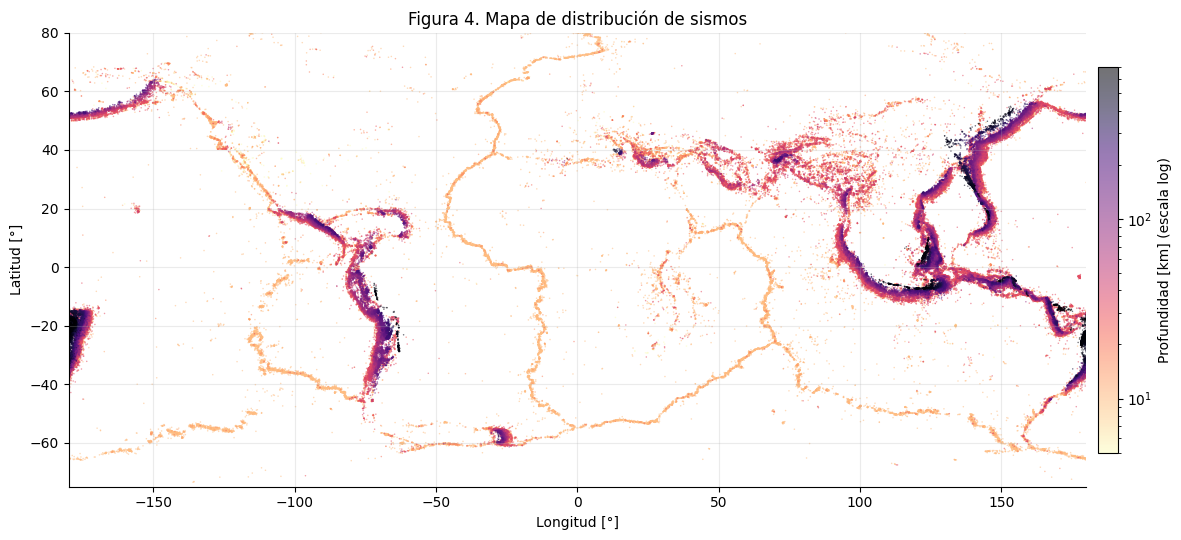

Profundidades más frecuentes:
    10.0 km :  72,712 eventos (27.6 %)
    33.0 km :  37,564 eventos (14.3 %)
    35.0 km :  10,992 eventos ( 4.2 %)
    30.0 km :   2,442 eventos ( 0.9 %)
     5.0 km :     815 eventos ( 0.3 %)


In [11]:
# Excluimos depth <= 0 (134 eventos en 0 exacto y 133 negativos) porque la escala es logarítmica
mapa = reciente[reciente.depth.notna() & (reciente.depth > 0)]
mapa = mapa.sort_values('depth')

fig, ax = plt.subplots(figsize=(13, 5.5))
sc = ax.scatter(mapa.longitude, mapa.latitude, c=mapa.depth, s=1.2,
                cmap='magma_r', norm=plt.matplotlib.colors.LogNorm(vmin=5, vmax=700),
                alpha=0.55, linewidths=0)
fig.colorbar(sc, ax=ax, label='Profundidad [km] (escala log)', pad=0.01, shrink=0.85)
ax.set(xlabel='Longitud [°]', ylabel='Latitud [°]', xlim=(-180, 180), ylim=(-75, 80),
       title='Figura 4. Mapa de distribución de sismos')
fig.tight_layout()
plt.show()

conteo_exactos = mapa.depth.value_counts().head(5)
print('Profundidades más frecuentes:')
for valor, n in conteo_exactos.items():
    print(f'  {valor:6.1f} km : {n:7,} eventos ({n/len(mapa)*100:4.1f} %)')

Se logra apreciar como los eventos profundos no aparecen dispersos, más bien se alinean en sectores especificos del mapa. (Colores oscuros) se podria decir que la profundidad puede describirse en función de la posición espacial (latitud y longitud)

Las profundidades más frecuentes revelan un detalle importante, hay una acumulación de eventos en 10km y 33km de profundidad. Estos valores corresponden a los valores por defecto que se asignan en caso de no ser posible determinar correctamente la profundidad.

## 9. Respuesta a la pregunta inicial

   **¿Podemos afirmar que últimamente está temblando más?**

**No,** con el analisis realizado, a partir de este catálogo podemos afirmar que efectivamente se registran más terremotos, pero no ocurren
más.

El número de registros de magnitud ≥ 4.5 casi se duplica entre 1980–1989 y 2020–2025 ( pasa de 3 936 a 7 623 por año).

Aún así ese aumento desaparece al subir la magnitud: desde M ≈ 5.0 el intervalo de confianza llega a 1, y en M ≥ 6.0 la tasa pasa de 125 a 133 eventos por año (×1.06, IC [0.89, 1.26]).
  
La pendiente de la distribución magnitud–frecuencia se mantiene en b ≈ 1.0 en las cinco décadas.

Un aumento uniforme de la sismicidad tendría que afectar también a los terremotos
grandes, que se detectan globalmente desde hace décadas y cuyo conteo no depende de la mejora
instrumental. Como el exceso corresponde al borde inferior del catálogo, la mejor explicación es una mejora de la completitud (Se lograron detectar más sismos) y la capacidad de detección. También puede ser la
evolución de los métodos de estimación de magnitud y otras diferencias observacionales que cambien el tipo de analisis.

Para responder mejor faltaria un catalogo en un única escala de magnitud. Conocer el limite de medición por año para conocer hasta que valor se logró medir efectivamente. Eliminar las replicas para reducir el "ruido" de la muestra y evitar llegar a conclusiones a partir de datos que no deben considerarse.

## 10. Conclusión

Los terremotos se duplican en las últimas decadas, pero al analizar las magnitudes, este aumento no se reparte de buena forma por todo el intervalo. La mayor diferencia está en los terremotos magnitud 5.0, siendo esta la distribución más similar para todos los periodos, a diferencia del limite inferior (menores magnitudes).
Esto dificulta la respuesta a la pregunta general, si los terremodot han aumentado. Aún así el patrón es compatible con la capacidad de detección del catálogo, aunque la evolución de los métodos de estimación de magnitud y otras diferencias observacionales también limitan la interpretación.

Aprendimos que las filas no son independientes, varias de esta constan de replicas (esto también genera ruido en el analisis de datos). El catalogo no es homogeneo respecto al tiempo, el tipo de magnituda cambia en varias ocaciones. Por último contiene valores fijos derivados de la misma medición (10 y 33 km).


## 11. Posible problema de Machine Learning

A partir del analisis eploratorio realizado, proponemos el siguiente problema de Machine Learning:

  **Predecir la profundidad de un evento ya detectado**

Para esto modelariamos el sistema por categorías: superficial, intermedia o profunda. De tal forma que terminaría siendo un problema de clásificación.

Predecidiriamos la categoría de profundidad de un evento, para esto definmos las categorias de la siguiente forma:

 1. Superficial (< 70 km)
 2. Intermedia (70–300 km)
 3. Profunda (> 300 km)

El dataset nos proporciona muchas variables de utilidad para cumplir la meta, de esta forma los features que se utilizarian serían: `latitude`, `longitude`, `mag`, `magType`. Las variables como `place` y `depth` se descartan, esta última ya que es la variable que buscamos predecir.

Este seria un problema de clásificación ya que el objetivo del moedelo es clasificar los datos en **categorias** definidas. En caso de querer predecir la profundidad exacta, el problema pasaría a ser un problema de regresión y eso dejaría de pertenecer a Machine Learning.

La Figura 4 especificamente, muestra que la profundidad no está
distribuida al azar, se ve como los eventos más profundos se concentran en sectores especificos, por lo que la posición geográfica (latitud y longitud) contiene gran parte de la información necesaria.

Aún así este modelo podria presentar dificultades, por ejemplo para la variable `depth` faltan muchos datos, en su mayoria para años inciales en el data set, lo que afectaria en el entrenamiento.
Puede que el modelo termine memorizando regiones, en ves de relizar una categorización correcta, lo que nos terminaria dando conclusiones erroneas.